# 객체 탐지 비교 실습: R-CNN 계열 vs YOLO

**Faster R-CNN**과, **YOLO**를 같은 이미지에 직접 돌려보고, 속도·정확도·탐지 결과를 비교해봅시다 !

**실습 목표**
-  **추론 속도** 차이를 직접 측정
- 두 모델의 **탐지 결과(박스 개수, confidence, 위치 정확도)** 를 비교
- 결과를 바탕으로 **왜 성능이 다른지** 스스로 분석하고 답 작성

**⚠️ 시작 전에**: 상단 메뉴에서 `런타임(Runtime) → 런타임 유형 변경(Change runtime type) → 하드웨어 가속기: GPU` 로 설정하세요. GPU 없이도 실행되지만 속도 비교가 왜곡될 수 있습니다.


## 목차
1. 환경 설정
2. 샘플 이미지 준비
3. Faster R-CNN 실습
4. YOLO 실습
5. 정량적 비교: 속도
6. 정량적 비교: 탐지 결과
7. 여러 이미지로 확장 비교
8. 생각해보기 (실습 문제 + 답안 작성)


## 1. 환경 설정

`torchvision`은 Colab에 기본 설치되어 있어 Faster R-CNN을 바로 쓸 수 있습니다. YOLO는 `ultralytics` 패키지를 설치합니다.

In [1]:
!pip install -q ultralytics
!apt-get install -qq -y fonts-nanum > /dev/null

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.0 MB/s eta 0:00:00


In [2]:
import time
import urllib.request

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from PIL import Image

from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)

# matplotlib 한글 폰트 (그래프 제목이 깨지지 않도록)
try:
    import matplotlib.font_manager as fm
    fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
    print("한글 폰트 적용 완료")
except Exception as e:
    print("한글 폰트 적용 실패, 기본 폰트로 진행:", e)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
device: cuda
torch: 2.11.0+cu128 | torchvision: 0.26.0+cu128
한글 폰트 적용 완료


## 2. 샘플 이미지 준비

COCO val2017에서 성격이 다른 이미지 세 장을 받습니다.

- `dinner`: 사람 18명이 서로 겹쳐 있고 컵, 와인잔, 포크 같은 작은 식기가 많은 실내 장면
- `living_room`: TV, 의자, 화분, 화병 등이 여러 크기로 흩어져 있는 거실 장면
- `street`: 사람과 신호등, 우산 정도만 있는 비교적 단순한 야외 장면

객체 밀도가 다른 이미지를 섞어두면 두 모델의 차이가 어디서 커지는지 보기 쉽습니다.
다른 URL로 바꿔 실험해보셔도 좋습니다.

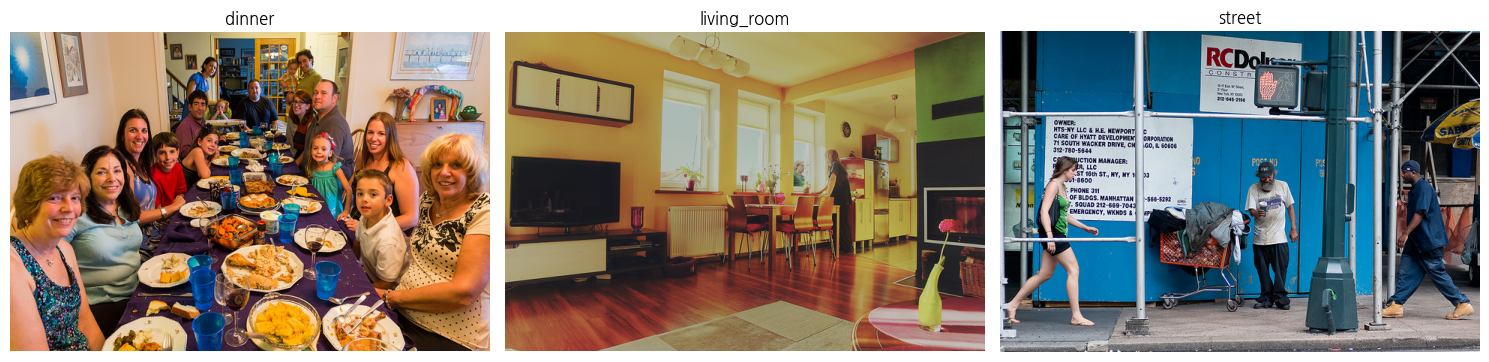

In [3]:
IMAGE_URLS = {
    # 사람이 겹치고 작은 식기가 많은 실내
    "dinner": "http://images.cocodataset.org/val2017/000000018380.jpg",
    # 여러 크기의 물체가 흩어진 거실
    "living_room": "http://images.cocodataset.org/val2017/000000000139.jpg",
    # 물체 수가 적은 야외 장면
    "street": "http://images.cocodataset.org/val2017/000000252219.jpg",
}

image_paths = {}
for name, url in IMAGE_URLS.items():
    path = f"{name}.jpg"
    urllib.request.urlretrieve(url, path)
    image_paths[name] = path

fig, axes = plt.subplots(1, len(image_paths), figsize=(15, 5))
for ax, (name, path) in zip(axes, image_paths.items()):
    ax.imshow(Image.open(path))
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Faster R-CNN

In [4]:
# COCO 클래스 이름 (torchvision 사전학습 모델 기준)
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A',
    'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli',
    'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# 사전학습된 Faster R-CNN (ResNet50 + FPN backbone) 로드
frcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
frcnn_model.to(device).eval()
print("Faster R-CNN 로드 완료")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 190MB/s]


Faster R-CNN 로드 완료


In [5]:
def run_faster_rcnn(image_path, score_threshold=0.6):
    """Faster R-CNN으로 추론하고 (박스, 라벨, 점수, 추론시간[초])을 반환"""
    img = Image.open(image_path).convert("RGB")
    tensor = torchvision.transforms.functional.to_tensor(img).to(device)

    with torch.no_grad():
        if device == "cuda":
            torch.cuda.synchronize()
        start = time.time()
        output = frcnn_model([tensor])[0]
        if device == "cuda":
            torch.cuda.synchronize()
        elapsed = time.time() - start

    keep = output["scores"] >= score_threshold
    boxes = output["boxes"][keep].cpu().numpy()
    labels = output["labels"][keep].cpu().numpy()
    scores = output["scores"][keep].cpu().numpy()
    return img, boxes, labels, scores, elapsed


def draw_boxes(ax, img, boxes, labels, scores, class_names, box_color="red"):
    ax.imshow(img)
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=box_color, facecolor="none")
        ax.add_patch(rect)
        name = class_names[label] if isinstance(class_names, list) else class_names.get(int(label), str(label))
        ax.text(x1, max(y1 - 5, 0), f"{name} {score:.2f}",
                 color="white", fontsize=8,
                 bbox=dict(facecolor=box_color, alpha=0.7, pad=1))
    ax.axis("off")


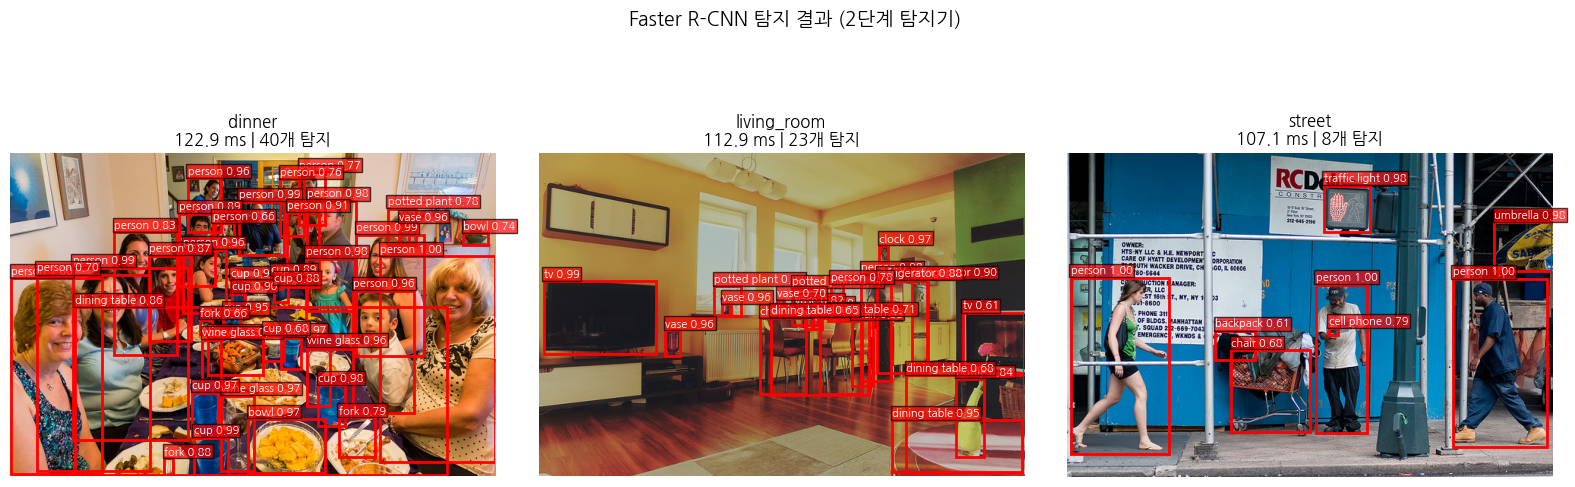

In [6]:
# Faster R-CNN 워밍업 (첫 실행은 GPU 초기화 등으로 느리므로 측정에서 제외)
_ = run_faster_rcnn(list(image_paths.values())[0])

fig, axes = plt.subplots(1, len(image_paths), figsize=(16, 6))
frcnn_results = {}
for ax, (name, path) in zip(axes, image_paths.items()):
    img, boxes, labels, scores, elapsed = run_faster_rcnn(path)
    frcnn_results[name] = dict(boxes=boxes, labels=labels, scores=scores, time=elapsed)
    draw_boxes(ax, img, boxes, labels, scores, COCO_CLASSES, box_color="red")
    ax.set_title(f"{name}\n{elapsed*1000:.1f} ms | {len(boxes)}개 탐지")
plt.suptitle("Faster R-CNN 탐지 결과 (2단계 탐지기)", fontsize=14)
plt.tight_layout()
plt.show()


## 4. YOLO

모델은 원본 모델이 아닌 ultralytics에서 지원하는 YOLOv5 모델을 활용하겠습니다.

원하신다면 최신 모델은 yolov8도 해보시는 것을 추천드립니다 !

In [7]:
yolo_model = YOLO("yolov5n.pt")  # nano 버전: 가장 가볍고 빠름
print("YOLOv5 로드 완료")

PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.
YOLOv5 로드 완료


In [8]:
def run_yolo(image_path, conf_threshold=0.6):
    """YOLOv5로 추론하고 (박스, 라벨, 점수, 추론시간[초])을 반환"""
    if device == "cuda":
        torch.cuda.synchronize()
    start = time.time()
    results = yolo_model.predict(image_path, conf=conf_threshold, device=device, verbose=False)
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start

    r = results[0]
    boxes = r.boxes.xyxy.cpu().numpy()
    labels = r.boxes.cls.cpu().numpy().astype(int)
    scores = r.boxes.conf.cpu().numpy()
    img = Image.open(image_path).convert("RGB")
    return img, boxes, labels, scores, elapsed, r.names


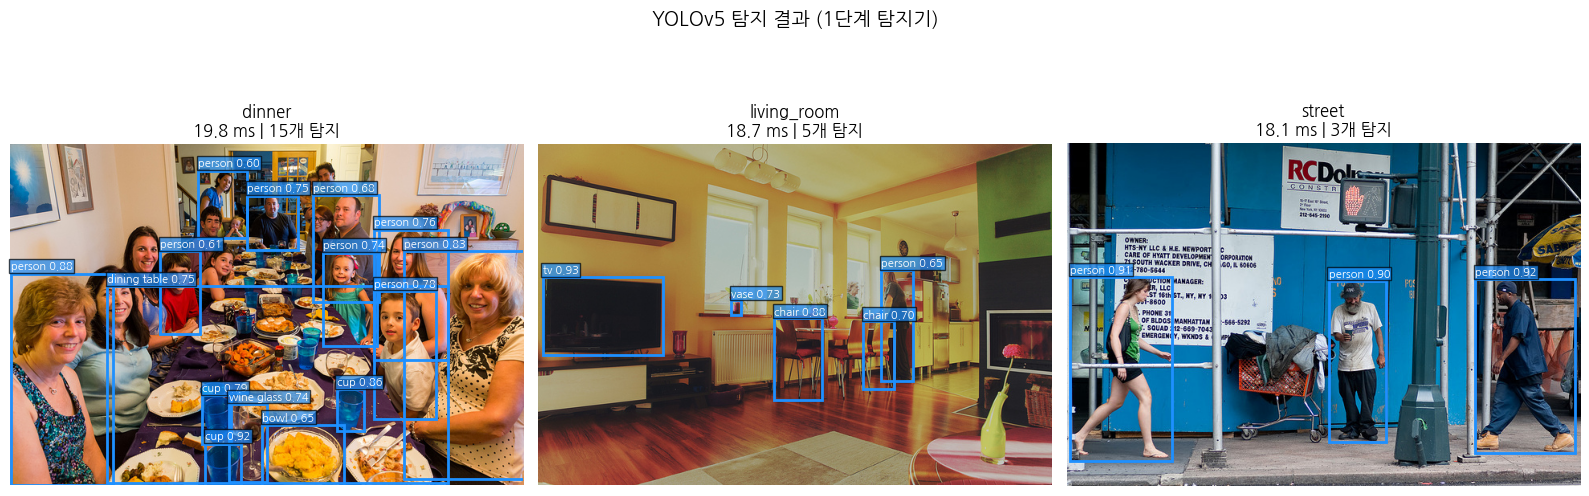

In [9]:
# YOLO 워밍업
_ = run_yolo(list(image_paths.values())[0])

fig, axes = plt.subplots(1, len(image_paths), figsize=(16, 6))
yolo_results = {}
for ax, (name, path) in zip(axes, image_paths.items()):
    img, boxes, labels, scores, elapsed, names = run_yolo(path)
    yolo_results[name] = dict(boxes=boxes, labels=labels, scores=scores, time=elapsed)
    draw_boxes(ax, img, boxes, labels, scores, names, box_color="dodgerblue")
    ax.set_title(f"{name}\n{elapsed*1000:.1f} ms | {len(boxes)}개 탐지")
plt.suptitle("YOLOv5 탐지 결과 (1단계 탐지기)", fontsize=14)
plt.tight_layout()
plt.show()


## 5. 정량적 비교: 속도

한 번의 측정은 노이즈가 클 수 있으므로, 같은 이미지를 여러 번 반복 추론해 **평균 시간**을 비교합니다.

In [10]:
N_RUNS = 20
speed_records = []

for name, path in image_paths.items():
    frcnn_times = [run_faster_rcnn(path)[4] for _ in range(N_RUNS)]
    yolo_times = [run_yolo(path)[4] for _ in range(N_RUNS)]
    speed_records.append({
        "image": name,
        "Faster R-CNN 평균(ms)": np.mean(frcnn_times) * 1000,
        "YOLOv5 평균(ms)": np.mean(yolo_times) * 1000,
    })

speed_df = pd.DataFrame(speed_records)
speed_df["속도 배율 (R-CNN / YOLO)"] = (
    speed_df["Faster R-CNN 평균(ms)"] / speed_df["YOLOv5 평균(ms)"]
).round(2)
speed_df


,image,Faster R-CNN 평균(ms),YOLOv5 평균(ms),속도 배율 (R-CNN / YOLO)
0,dinner,116.123533,12.431896,9.34
1,living_room,113.013804,11.558211,9.78
2,street,113.281333,11.303937,10.02


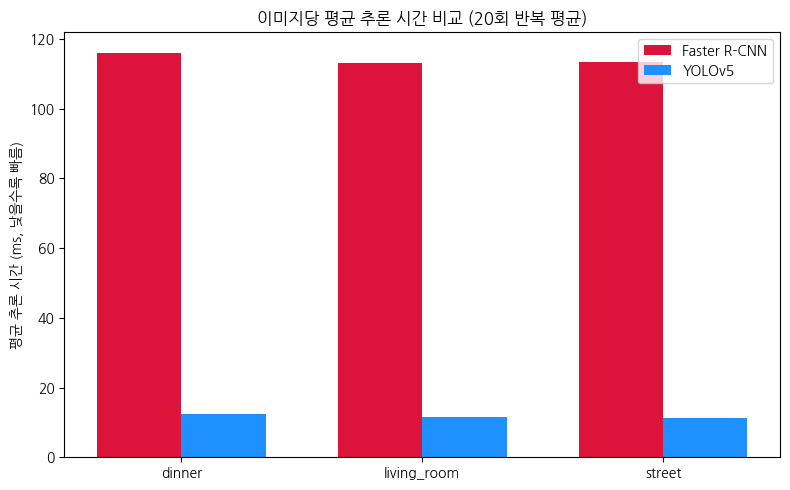

In [11]:
x = np.arange(len(speed_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, speed_df["Faster R-CNN 평균(ms)"], width, label="Faster R-CNN", color="crimson")
ax.bar(x + width/2, speed_df["YOLOv5 평균(ms)"], width, label="YOLOv5", color="dodgerblue")
ax.set_xticks(x)
ax.set_xticklabels(speed_df["image"])
ax.set_ylabel("평균 추론 시간 (ms, 낮을수록 빠름)")
ax.set_title(f"이미지당 평균 추론 시간 비교 ({N_RUNS}회 반복 평균)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. 정량적 비교: 탐지 결과

같은 이미지, 같은 confidence 임계값(0.6)에서 두 모델이 **몇 개의 물체를 찾았는지**, **평균 confidence는 얼마인지** 비교합니다.

In [12]:
detect_records = []
for name, path in image_paths.items():
    f = frcnn_results[name]
    y = yolo_results[name]
    detect_records.append({
        "image": name,
        "R-CNN 탐지 개수": len(f["boxes"]),
        "YOLO 탐지 개수": len(y["boxes"]),
        "R-CNN 평균 confidence": round(float(np.mean(f["scores"])), 3) if len(f["scores"]) else None,
        "YOLO 평균 confidence": round(float(np.mean(y["scores"])), 3) if len(y["scores"]) else None,
    })

detect_df = pd.DataFrame(detect_records)
detect_df


,image,R-CNN 탐지 개수,YOLO 탐지 개수,R-CNN 평균 confidence,YOLO 평균 confidence
0,dinner,40,15,0.888,0.755
1,living_room,23,5,0.868,0.776
2,street,8,3,0.879,0.911


## 8. 🧠 생각해보기 (실습 문제)

위에서 측정한 결과를 바탕으로 아래 질문에 직접 답을 작성해보세요 !

### Q1. 누가 더 빨랐나요 ? 속도 차이가 어느정도 나는지 적어주세요

**✏️ 답안 작성:**

> YOLO가 Faster R-CNN보다 빨랐으며, 이미지에 따라 약 9.3~10.0배 정도 차이가 났다.


### Q2. 왜 Faster R-CNN이 YOLO보다 느릴까요?

두 모델의 **구조적 차이**를 바탕으로, 속도 차이가 발생하는 이유를 설명해보세요.

**✏️ 답안 작성:**

> Faster R-CNN은 먼저 객체가 있을 만한 영역을 찾은 뒤 분류하는 2단계 방식인 반면, YOLO는 한 번에 객체의 위치와 클래스를 예측하기 때문에 더 빠르다.


### Q3. 탐지 개수나 confidence에 차이가 있었나요?

**✏️ 답안 작성:**

> Faster R-CNN이 모든 이미지에서 더 많은 객체를 탐지했고, 평균 confidence도 대체로 높았다. 반면 street에서는 YOLO의 confidence가 0.911로 더 높았다.

### Q4. 탐지 개수나 confidence에서 왜 차이가 나는지 고민해보고 답을 작성해주세요.

**📝 답안 작성:**

> Faster R-CNN은 객체 후보를 여러 단계에서 확인해 더 많은 객체를 잡는 반면, YOLO는 한 번에 예측하면서 상대적으로 탐지 개수가 적게 나온 것으로 보인다. 같은 0.6 기준을 사용해도 두 모델의 예측 특성이 달라 confidence에도 차이가 나타났다.

답변은 정답을 원하는게 아닙니다 ! 스스로 결과를 보고 왜 그렇게 나왔는지 고민해보고 편하게 작성해주세요 !! 그럼 오늘도 수고하셨습니다😊